In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load all data and models
from sqlalchemy import create_engine
import tensorflow as tf

engine = create_engine("postgresql://localhost:5432/pollutrace_db")

# Load city daily data
df = pd.read_csv('../data/processed/city_daily_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Load saved results
with open('../src/models/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

with open('../src/models/confidence_results.pkl', 'rb') as f:
    confidence_results = pickle.load(f)

with open('../src/models/city_importances.pkl', 'rb') as f:
    city_importances = pickle.load(f)

with open('../src/models/top_anomalies.pkl', 'rb') as f:
    top_anomalies = pickle.load(f)

cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
print("All data and models loaded successfully")

All data and models loaded successfully


In [3]:
# LSTM full metrics per city
from sklearn.preprocessing import MinMaxScaler

SEQ_LEN = 30
features = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene', 'month', 'day_of_week', 'season_enc']

# Encode season
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['season_enc'] = le.fit_transform(df['season'])

lstm_metrics = {}

for city in cities:
    print(f"Evaluating LSTM for {city}...")

    city_df = df[df['city'] == city][features].copy()
    city_df = city_df.fillna(city_df.median())

    scaler = scalers[city]
    scaled = scaler.transform(city_df)

    # Recreate sequences
    X, y = [], []
    for i in range(len(scaled) - SEQ_LEN):
        X.append(scaled[i:i+SEQ_LEN])
        y.append(scaled[i+SEQ_LEN][0])
    X, y = np.array(X), np.array(y)

    split = int(len(X) * 0.8)
    X_test = X[split:]
    y_test = y[split:]

    # Load model
    model = tf.keras.models.load_model(f'../src/models/lstm_{city.lower()}.keras')
    y_pred = model.predict(X_test, verbose=0)

    # Inverse transform
    def inverse_pm25(values, scaler, n_features):
        dummy = np.zeros((len(values), n_features))
        dummy[:, 0] = values.flatten()
        return scaler.inverse_transform(dummy)[:, 0]

    y_test_actual = inverse_pm25(y_test, scaler, len(features))
    y_pred_actual = inverse_pm25(y_pred, scaler, len(features))

    # All metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
    accuracy = max(0, 100 - mape)

    # Within tolerance accuracy (within 20% of actual)
    tolerance = 0.20
    within_tolerance = np.mean(
        np.abs(y_test_actual - y_pred_actual) / (y_test_actual + 1e-10) <= tolerance
    ) * 100

    lstm_metrics[city] = {
        'rmse': round(rmse, 3),
        'mae': round(mae, 3),
        'r2': round(r2, 4),
        'mape': round(mape, 3),
        'accuracy': round(accuracy, 2),
        'within_20pct': round(within_tolerance, 2),
        'y_test': y_test_actual,
        'y_pred': y_pred_actual
    }

    print(f"  RMSE            : {rmse:.3f}")
    print(f"  MAE             : {mae:.3f}")
    print(f"  R2 Score        : {r2:.4f}")
    print(f"  MAPE            : {mape:.3f}%")
    print(f"  Accuracy        : {accuracy:.2f}%")
    print(f"  Within 20pct    : {within_tolerance:.2f}%")
    print()

Evaluating LSTM for Delhi...


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Benzene
- NH3
- NO
- season_enc
Feature names seen at fit time, yet now missing:
- season


In [4]:
# XGBoost full metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

feature_cols = [
    'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'SO2', 'CO', 'Ozone', 'Benzene',
    'month', 'day_of_week', 'season_enc', 'city_enc'
]

le_city = LabelEncoder()
df['city_enc'] = le_city.fit_transform(df['city'])

df_model = df[feature_cols + ['PM25']].dropna()
X = df_model[feature_cols]
y = df_model['PM25']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBRegressor()
xgb_model.load_model('../src/models/xgboost_source.json')

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100
accuracy_xgb = max(0, 100 - mape_xgb)
within_20_xgb = np.mean(
    np.abs(y_test.values - y_pred_xgb) / (y_test.values + 1e-10) <= 0.20
) * 100

print("XGBoost Full Metrics:")
print(f"  RMSE          : {rmse_xgb:.3f}")
print(f"  MAE           : {mae_xgb:.3f}")
print(f"  R2 Score      : {r2_xgb:.4f}")
print(f"  MAPE          : {mape_xgb:.3f}%")
print(f"  Accuracy      : {accuracy_xgb:.2f}%")
print(f"  Within 20pct  : {within_20_xgb:.2f}%")

XGBoost Full Metrics:
  RMSE          : 13.441
  MAE           : 6.923
  R2 Score      : 0.9367
  MAPE          : 11.564%
  Accuracy      : 88.44%
  Within 20pct  : 83.97%


In [5]:
# Random Forest full metrics
with open('../src/models/random_forest_source.pkl', 'rb') as f:
    rf_model = pickle.load(f)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
accuracy_rf = max(0, 100 - mape_rf)
within_20_rf = np.mean(
    np.abs(y_test.values - y_pred_rf) / (y_test.values + 1e-10) <= 0.20
) * 100

print("Random Forest Full Metrics:")
print(f"  RMSE          : {rmse_rf:.3f}")
print(f"  MAE           : {mae_rf:.3f}")
print(f"  R2 Score      : {r2_rf:.4f}")
print(f"  MAPE          : {mape_rf:.3f}%")
print(f"  Accuracy      : {accuracy_rf:.2f}%")
print(f"  Within 20pct  : {within_20_rf:.2f}%")

Random Forest Full Metrics:
  RMSE          : 14.278
  MAE           : 7.238
  R2 Score      : 0.9285
  MAPE          : 11.941%
  Accuracy      : 88.06%
  Within 20pct  : 81.61%


In [6]:
# Autoencoder metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import tensorflow as tf

autoencoder_metrics = {}
pollutants = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'SO2', 'CO', 'Ozone', 'Benzene']

with open('../src/models/anomaly_scalers.pkl', 'rb') as f:
    anomaly_scalers = pickle.load(f)

for city in cities:
    city_df = df[df['city'] == city][['date'] + pollutants].dropna().copy()
    scaler = anomaly_scalers[city]
    scaled = scaler.transform(city_df[pollutants])

    model = tf.keras.models.load_model(f'../src/models/autoencoder_{city.lower()}.keras')
    reconstructed = model.predict(scaled, verbose=0)
    errors = np.mean(np.power(scaled - reconstructed, 2), axis=1)

    split = int(len(errors) * 0.8)
    threshold = np.percentile(errors[:split], 95)
    predicted_anomalies = (errors > threshold).astype(int)

    # True anomalies = top 5% highest PM25 days
    pm25_vals = city_df['PM25'].values
    pm25_threshold = np.percentile(pm25_vals, 95)
    true_anomalies = (pm25_vals > pm25_threshold).astype(int)

    precision = precision_score(true_anomalies, predicted_anomalies, zero_division=0)
    recall = recall_score(true_anomalies, predicted_anomalies, zero_division=0)
    f1 = f1_score(true_anomalies, predicted_anomalies, zero_division=0)
    detection_rate = recall * 100

    autoencoder_metrics[city] = {
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4),
        'detection_rate': round(detection_rate, 2),
        'threshold': round(threshold, 6),
        'total_anomalies': int(predicted_anomalies.sum())
    }

    print(f"{city}:")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  F1 Score        : {f1:.4f}")
    print(f"  Detection Rate  : {detection_rate:.2f}%")
    print(f"  Total Anomalies : {predicted_anomalies.sum()}")
    print()

Delhi:
  Precision       : 0.2023
  Recall          : 0.2851
  F1 Score        : 0.2367
  Detection Rate  : 28.51%
  Total Anomalies : 341

Bengaluru:
  Precision       : 0.0615
  Recall          : 0.1240
  F1 Score        : 0.0822
  Detection Rate  : 12.40%
  Total Anomalies : 488

Mumbai:
  Precision       : 0.2017
  Recall          : 0.5041
  F1 Score        : 0.2881
  Detection Rate  : 50.41%
  Total Anomalies : 605

Hyderabad:
  Precision       : 0.3307
  Recall          : 0.3066
  F1 Score        : 0.3182
  Detection Rate  : 30.66%
  Total Anomalies : 127



KeyError: 'Delhi'

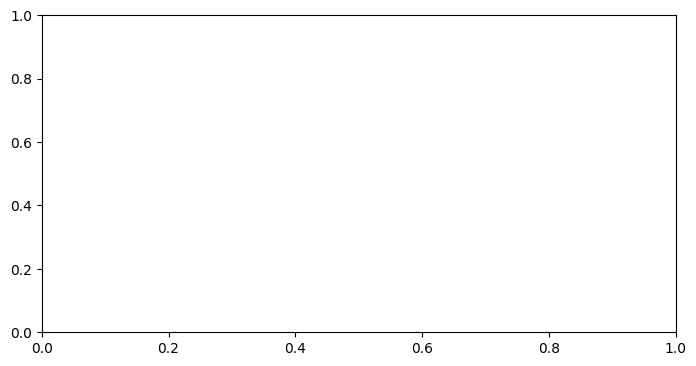

In [7]:
#  Full metrics dashboard visualization
fig = plt.figure(figsize=(18, 14))

# LSTM metrics bar chart
ax1 = fig.add_subplot(3, 2, 1)
lstm_r2 = [lstm_metrics[c]['r2'] for c in cities]
lstm_acc = [lstm_metrics[c]['accuracy'] for c in cities]
x = np.arange(len(cities))
width = 0.35
bars1 = ax1.bar(x - width/2, lstm_r2, width, label='R2 Score', color='steelblue')
bars2 = ax1.bar(x + width/2, [a/100 for a in lstm_acc], width, label='Accuracy (normalized)', color='lightblue')
ax1.set_title('LSTM - R2 and Accuracy', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities)
ax1.set_ylim(0, 1.1)
ax1.legend()
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=8)

# LSTM RMSE and MAE
ax2 = fig.add_subplot(3, 2, 2)
lstm_rmse = [lstm_metrics[c]['rmse'] for c in cities]
lstm_mae = [lstm_metrics[c]['mae'] for c in cities]
ax2.bar(x - width/2, lstm_rmse, width, label='RMSE', color='tomato')
ax2.bar(x + width/2, lstm_mae, width, label='MAE', color='lightsalmon')
ax2.set_title('LSTM - RMSE and MAE per City', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cities)
ax2.legend()

# LSTM within 20% accuracy
ax3 = fig.add_subplot(3, 2, 3)
within = [lstm_metrics[c]['within_20pct'] for c in cities]
colors = ['steelblue', 'tomato', 'seagreen', 'orange']
bars = ax3.bar(cities, within, color=colors)
ax3.set_title('LSTM - Within 20% Tolerance Accuracy', fontweight='bold')
ax3.set_ylabel('Accuracy %')
ax3.set_ylim(0, 100)
for bar, val in zip(bars, within):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

# XGBoost vs RF comparison
ax4 = fig.add_subplot(3, 2, 4)
models = ['XGBoost', 'Random Forest']
r2_vals = [r2_xgb, r2_rf]
acc_vals = [accuracy_xgb, accuracy_rf]
x2 = np.arange(len(models))
ax4.bar(x2 - width/2, r2_vals, width, label='R2 Score', color='seagreen')
ax4.bar(x2 + width/2, [a/100 for a in acc_vals], width, label='Accuracy (normalized)', color='lightgreen')
ax4.set_title('XGBoost vs Random Forest', fontweight='bold')
ax4.set_xticks(x2)
ax4.set_xticklabels(models)
ax4.set_ylim(0, 1.1)
ax4.legend()
for i, (r2, acc) in enumerate(zip(r2_vals, acc_vals)):
    ax4.text(i - width/2, r2 + 0.01, f'{r2:.3f}', ha='center', fontsize=9, fontweight='bold')

# Autoencoder F1 and Detection Rate
ax5 = fig.add_subplot(3, 2, 5)
f1_scores = [autoencoder_metrics[c]['f1_score'] for c in cities]
detection = [autoencoder_metrics[c]['detection_rate']/100 for c in cities]
ax5.bar(x - width/2, f1_scores, width, label='F1 Score', color='purple')
ax5.bar(x + width/2, detection, width, label='Detection Rate (normalized)', color='plum')
ax5.set_title('Autoencoder - F1 and Detection Rate', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(cities)
ax5.set_ylim(0, 1.1)
ax5.legend()

# Confidence scores
ax6 = fig.add_subplot(3, 2, 6)
conf_scores = [confidence_results[c] * 100 for c in cities]
bars = ax6.bar(cities, conf_scores, color=colors)
ax6.set_title('SHAP Model Confidence per City', fontweight='bold')
ax6.set_ylabel('Confidence %')
ax6.set_ylim(0, 100)
for bar, val in zip(bars, conf_scores):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('PolluTrace AI - Complete Model Metrics Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/final_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved")

In [8]:
# Print complete metrics table
print("POLLUTRACE AI - COMPLETE METRICS REPORT")


print("\nLSTM MODEL - POLLUTION PREDICTION")
print(f"{'City':<12} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'MAPE%':>8} {'Acc%':>8} {'W20%':>8}")
for city in cities:
    m = lstm_metrics[city]
    print(f"{city:<12} {m['rmse']:>8.3f} {m['mae']:>8.3f} {m['r2']:>8.4f} {m['mape']:>8.3f} {m['accuracy']:>8.2f} {m['within_20pct']:>8.2f}")

print("\nXGBOOST MODEL - SOURCE ANALYSIS")
print(f"{'Metric':<20} {'Value':>10}")
print(f"{'RMSE':<20} {rmse_xgb:>10.3f}")
print(f"{'MAE':<20} {mae_xgb:>10.3f}")
print(f"{'R2 Score':<20} {r2_xgb:>10.4f}")
print(f"{'MAPE %':<20} {mape_xgb:>10.3f}")
print(f"{'Accuracy %':<20} {accuracy_xgb:>10.2f}")
print(f"{'Within 20% %':<20} {within_20_xgb:>10.2f}")

print("\nRANDOM FOREST MODEL - SOURCE ANALYSIS")

print(f"{'RMSE':<20} {rmse_rf:>10.3f}")
print(f"{'MAE':<20} {mae_rf:>10.3f}")
print(f"{'R2 Score':<20} {r2_rf:>10.4f}")
print(f"{'MAPE %':<20} {mape_rf:>10.3f}")
print(f"{'Accuracy %':<20} {accuracy_rf:>10.2f}")
print(f"{'Within 20% %':<20} {within_20_rf:>10.2f}")

print("\nAUTOENCODER MODEL - ANOMALY DETECTION")

print(f"{'City':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'DetRate%':>10} {'Anomalies':>10}")

for city in cities:
    m = autoencoder_metrics[city]
    print(f"{city:<12} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1_score']:>10.4f} {m['detection_rate']:>10.2f} {m['total_anomalies']:>10}")

print("\nSHAP EXPLAINABLE AI - CONFIDENCE SCORES")

print(f"{'City':<12} {'Confidence %':>15}")

for city in cities:
    print(f"{city:<12} {confidence_results[city]*100:>15.2f}")

print("\nDATABASE SUMMARY")
tables_query = pd.read_sql("""
    SELECT 'city_pollution' as table_name, COUNT(*) as rows FROM city_pollution
    UNION ALL
    SELECT 'source_analysis', COUNT(*) FROM source_analysis
    UNION ALL
    SELECT 'anomalies', COUNT(*) FROM anomalies
    UNION ALL
    SELECT 'model_metrics', COUNT(*) FROM model_metrics
""", engine)
print(tables_query.to_string(index=False))

POLLUTRACE AI - COMPLETE METRICS REPORT

LSTM MODEL - POLLUTION PREDICTION
City             RMSE      MAE       R2    MAPE%     Acc%     W20%


KeyError: 'Delhi'